# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Student Pass/Fail Prediction using the Student Performance Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, not on data cleaning.

### Objective
Build a baseline model to predict whether a student **passes** (final grade G3 ≥ 10) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoid leakage features)  
3) Engineer new features (study-based, behavior-based, family-based)  
4) Encode categorical features  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the dataset

In [ ]:
DATA_PATH = "student-mat (1).csv"
df = pd.read_csv(DATA_PATH, sep=";")

df.head(10)

The first rows confirm that the dataset loaded correctly.  
Each row represents one student, including demographic information, study habits, and grades (G1, G2, G3).

## 3. Quick dataset checks (cleanliness confirmation)

In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [ ]:
target_col = "pass"
df[target_col] = (df["G3"] >= 10).astype(int)

print("Class distribution:")
print(df[target_col].value_counts())
df[target_col].value_counts()

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x=target_col, data=df)
plt.title("Pass / Fail Distribution")
plt.xlabel("Pass (1 = G3 ≥ 10, 0 = Fail)")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the classification report.

## 5. Identify feature types

In [6]:
df.dtypes

Order_ID                       int64
User_ID                          str
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                        str
Quantity                       int64
Total_Price                  float64
Order_Time                       str
Delivery_Time                    str
Delivery_Duration_Minutes      int64
City                             str
Payment_Method                   str
Order_Status                     str
Driver_Vehicle                   str
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                    str
Driver_Availability              str
dtype: object

We have a mixture of numerical features (e.g., `age`, `absences`, `studytime`) and categorical features (e.g., `school`, `sex`, `Mjob`).  
This is a common real-world situation where feature engineering and encoding become essential.

## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict whether a student passes **at the start of the school year**, we should not use:
- `G1` (first period grade — known only later)
- `G2` (second period grade — known only later)

In this lab, we will **exclude** G1 and G2 to avoid leakage, and predict pass/fail from G3 using only demographic and behavioral features.

## 7. Feature engineering

### 7.1 Study & behavior features
We engineer features that capture student study habits and risk indicators:
- `total_alcohol` = daily + weekend alcohol consumption  
- `is_high_absences` = flag for students with more than 5 absences  
- `study_efficiency` = studytime divided by (failures + 1) — rewards studying while penalizing past failures

In [ ]:
df_fe = df.copy()

df_fe["total_alcohol"]     = df_fe["Dalc"] + df_fe["Walc"]
df_fe["is_high_absences"]  = (df_fe["absences"] > 5).astype(int)
df_fe["study_efficiency"]  = df_fe["studytime"] / (df_fe["failures"] + 1)

df_fe[["studytime", "failures", "absences", "Dalc", "Walc",
       "total_alcohol", "is_high_absences", "study_efficiency"]].head(10)

We transformed raw behavioral columns into meaningful summary features.  
Models often learn better from these engineered features than from individual raw columns.

### 7.2 Family education feature
We create a feature that captures the average parental education level:  
`avg_parent_edu = (Medu + Fedu) / 2`

This can help the model differentiate between students with highly educated parents (more support) and those with less-educated parents.

In [ ]:
df_fe["avg_parent_edu"] = (df_fe["Medu"] + df_fe["Fedu"]) / 2
df_fe[["Medu", "Fedu", "avg_parent_edu"]].head(10)

`avg_parent_edu` is a derived feature combining both parents' education levels into a single signal.  
It is an example of domain-driven feature engineering based on educational research.

### 7.3 At-risk composite flag
We combine two risk indicators — past failures and high absences — into a single binary flag.  
This is an example of creating a **composite feature** from multiple existing features.

In [ ]:
df_fe["is_at_risk"] = ((df_fe["failures"] > 0) & (df_fe["absences"] > 5)).astype(int)

print("At-risk students:", df_fe["is_at_risk"].sum())
df_fe[["failures", "absences", "is_at_risk"]].head(10)

`is_at_risk` flags students who both have past failures and high absences.  
Such composite features can encode expert knowledge directly into the model.

### 7.4 Reducing high-cardinality categories (example: `reason`)
`reason` (reason for choosing the school) has a small but meaningful number of categories.  
We keep the top-k most frequent and map the rest to `Other` to demonstrate the approach.

In [ ]:
top_k = 3
top_reasons = df_fe["reason"].value_counts().head(top_k).index
df_fe["reason_reduced"] = np.where(df_fe["reason"].isin(top_reasons), df_fe["reason"], "Other")

print("Unique reason:", df_fe["reason"].nunique())
print("Unique reason_reduced:", df_fe["reason_reduced"].nunique())
df_fe[["reason", "reason_reduced"]].head(10)

We reduced the cardinality of a categorical feature.  
This often improves model stability and reduces overfitting, especially for baseline models.

## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `age` into student age groups.

In [ ]:
df_fe["age_group"] = pd.cut(
    df_fe["age"],
    bins=[14, 16, 18, 22],
    labels=["15-16", "17-18", "19+"]
)

df_fe[["age", "age_group"]].head(10)

`age_group` groups students into interpretable age brackets.  
Older students (19+) may have different study patterns or responsibilities that affect pass rates.

## 9. Prepare features for modeling

We now select our predictors.

We will drop:
- `G1`, `G2`, `G3` — leakage (G3 is the target; G1/G2 are future information)
- `reason` — replaced by `reason_reduced`

We will keep:
- all demographic, behavioral, and family features
- engineered features

In [ ]:
drop_cols = ["G1", "G2", "G3", "reason"]
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes both original student attributes and our engineered features.

## 10. Split into train and test sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (80000, 22)
Test size: (20000, 22)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.


## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [14]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model


Categorical columns: ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier']
Numeric columns: ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item', 'haversine_rest_to_cust_km']


C:\Users\AftabKhan\AppData\Local\Temp\ipykernel_28008\945966939.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## 12. Train the model and evaluate

In [15]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8519

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



C:\Users\AftabKhan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\AftabKhan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\AftabKhan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


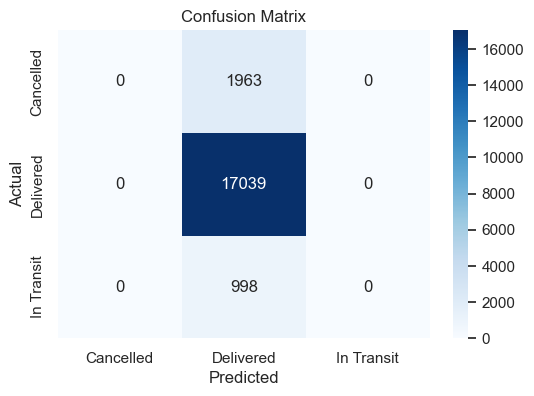

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [17]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
44,price_per_item,0.070257
35,Customer_Lat,0.069609
36,Customer_Lon,0.069482
37,Driver_Lat,0.069400
38,Driver_Lon,0.069326
34,Restaurant_Lon,0.069323
32,Total_Price,0.069176
33,Restaurant_Lat,0.068819
45,haversine_rest_to_cust_km,0.067491
39,Delivery_Distance_km,0.066953


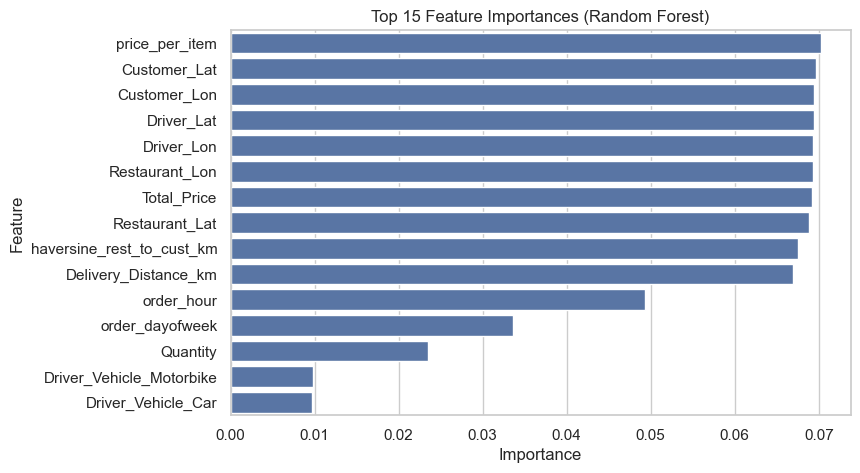

In [18]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.


## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [ ]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


If performance stays similar, feature selection may help simplify the model with minimal accuracy loss.  
If performance drops, it may indicate that important information was removed.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict whether a student passes.  
Write one paragraph justifying your choice.

### Task 2
Try a different threshold for `is_high_absences` (e.g., 10 instead of 5) and discuss whether model performance changes.

### Task 3
Change `top_k` in `reason_reduced` (for example 2, 3, 4) and compare:
- accuracy
- top feature importances

### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.

## Wrap-up
In this lab, the dataset was already clean, so our focus was on feature engineering.  
We engineered time-based, price-based, and category-reduction features, then evaluated a baseline classifier and interpreted feature importance.
